# Stromkosten einer WG

In diesem Kapitel schauen wir uns an, wie viel Strom in einer WG verbraucht wird – und was das letztlich kostet.
Dabei lernen wir zwei neue Dinge kennen:

Wir lernen Arrays aus dem Paket numpy kennen, mit denen man sehr bequem ganze Listen von Zahlen auf einmal bearbeiten kann.
Und wir lernen Dictionaries kennen, eine Datenstruktur, mit der man statt Zahlen (wie bei Listen) Wörter verwenden kann um etwas nachzuschlagen.

## Stromverbrauch pro Tag als Liste

Am Anfang steht eine ganz normale Python‑Liste.
Sie enthält den Stromverbrauch (in kWh) für jeden Tag über vier Wochen, die wir aus einem Smartmeter bekommen können.
Die Liste sieht so aus:


In [1]:
daily_consumption_kwh = [8.0, 7.5, 7.8, 8.2, 12.0, 5.5, 5.0, 8.1, 7.6, 7.9, 8.3, 
                         12.5, 5.3, 5.1, 8.2, 7.4, 7.7, 8.4, 12.2, 5.4, 5.2, 8.3, 7.7, 7.6, 8.1, 12.7, 5.2, 5.3]

Jedes Element in dieser Liste steht für einen Tag. Die Reihenfolge entspricht der Zeit: ganz links der erste Tag, ganz rechts der letzte Tag.

Fürs erste plotten wir diese Liste einfach mal:

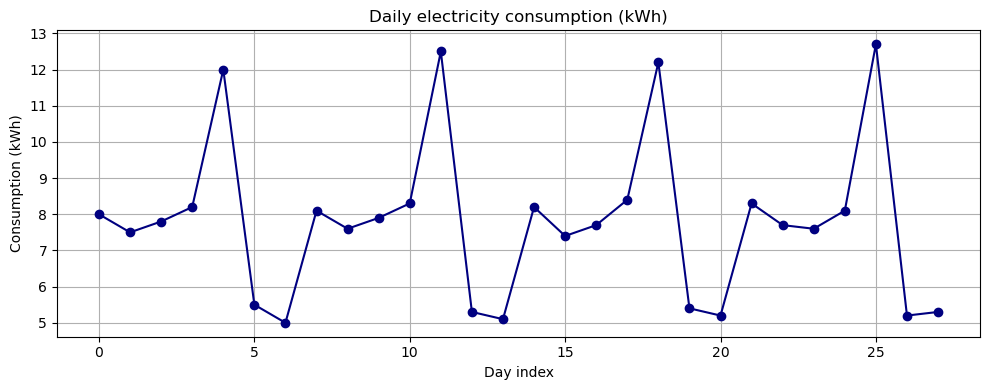

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(daily_consumption_kwh, color="navy", marker="o")
plt.title("Daily electricity consumption (kWh)")
plt.xlabel("Day index")
plt.ylabel("Consumption (kWh)")
plt.grid(True)
plt.tight_layout()
plt.show()

Hier wird der Stromverbrauch pro Tag als Linie mit Punkten eingezeichnet.
Die x‑Achse zeigt den „Day index“: 0 ist der erste Tag, 1 der zweite Tag und so weiter.
Auf der y‑Achse sehen wir den Verbrauch in kWh.
So bekommen wir einen ersten Überblick, wie der Stromverbrauch über die vier Wochen verteilt ist.

## Von kWh zu Kosten
Für die WG sind die kWh an sich nicht das Spannendste.
Wichtiger ist die Frage: „Wie viel kostet uns jeder Tag?“

Wir haben eine Liste mit Verbrauchswerten und einen Strompreis pro kWh.
Wir möchten für jeden Tag die kWh mit dem Preis multiplizieren und dadurch die Kosten pro Tag bekommen.

Bevor wir Arrays verwenden, schauen wir kurz, was passiert, wenn man in Python einfach eine Liste mit * multipliziert.

Nehmen wir eine kleine Beispiel‑Liste und untersuchen was passiert:

In [5]:
values = [10, 5, 2, 9]
values_times_two = values * 2
print(values_times_two)

[10, 5, 2, 9, 10, 5, 2, 9]


Python wiederholt hier die Liste, statt jedes Element mit 2 zu multiplizieren.
Die Liste wird zweimal hintereinander angeordnet, die Zahlen selbst bleiben gleich.
Das macht Sinn, wenn die Liste zum Beispiel eine Einkaufsliste wäre:

`["brot","milch","schokorosinen"] * 2 = ["brot","milch","schokorosinen","brot","milch","schokorosinen"]`

Bei Zahlen wollen wir aber eigentlich was anderes: Wir wollen, dass jede Zahl mit 2 multipliziert wird. Dazu müssten wir eine Schleife verwenden. Aber es geht auch einfacher: mit **arrays**.

## Numpy Arrays

Ein Array kann man sich vorstellen wie eine Liste, mit der der Computer leichter rechnen kann.
Wir verwenden dafür das Paket numpy.

Damit numpy im Programm verfügbar ist, muss es einmal installiert werden.
Das passiert im Terminal mit `pip install numpy`. Und am Anfang unseres Programms brauchen wir ein  `import numpy as np`.

Nun können wir unsere Liste in ein Array umwandeln und die Kosten berechnen:


In [7]:
import numpy as np
#(...)
price_per_kwh_eur = 0.30  # price in EUR per kWh

daily_consumption_array = np.array(daily_consumption_kwh)

# Element-wise multiplication: costs for each day
daily_costs_eur = daily_consumption_array * price_per_kwh_eur

Was hier passiert:

* `np.array(daily_consumption_kwh)` erzeugt ein neues Objekt, das sich sehr ähnlich wie eine Liste anfühlt, aber für Rechenoperationen optimiert ist.
* `daily_consumption_array * price_per_kwh_eur` multipliziert jedes Element des Arrays mit dem Strompreis.

Mit Arrays ist array * zahl genau das, was wir uns wünschen: jede Zahl in dieser Datenstruktur wird mit der Zahl multipliziert.
Wir müssen keine Schleife von Hand schreiben, der Code bleibt kurz und gut lesbar.

Den neuen Array mit den Kosten können wir genauso plotten wie vorher die Liste:

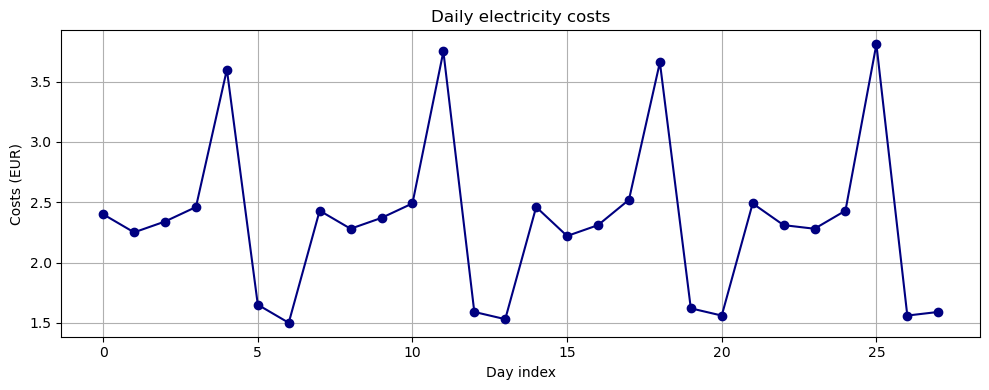

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(daily_costs_eur, color="navy", marker="o")
plt.title("Daily electricity costs")
plt.xlabel("Day index")
plt.ylabel("Costs (EUR)")
plt.grid(True)
plt.tight_layout()
plt.show()

Die Funktion plt.plot(...) akzeptiert nicht nur normale Listen als Argument, sondern auch numpy‑Arrays.
Wir können daily_costs_eur direkt übergeben.

Jetzt sehen wir im Plot die Kosten pro Tag.
Man erkennt deutlich, dass manche Tage wesentlich teurer sind als andere. Sehr mysteriös.....

## Wochentage nachschlagen

Im Kosten‑Plot scheint es ein Muster zu geben:
Einige Tage sind regelmäßig hoch, andere regelmäßig niedrig.
Unsere Vermutung ist, dass bestimmte Wochentage teurer sind, warum auch immer.

Für unsere Anwendung möchten wir die Zahlen 0 bis 6 auf Wochentagsnamen abbilden.
Auch dafür können wir eine Liste verwenden:

In [6]:
weekday_lookup = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

Wenn wir `weekday_lookup[4]` schreiben, bekommen wir "Friday" zurück.
Damit können wir aus einer Zahl sofort einen Wochentagsnamen machen.  
Das einzige Problem: Wir haben ja mehr als eine Woche. Aber die Lösung ist offensichtlich:  
Die Listen-Multiplikation von Python, macht genau das, was wir hier wollen.

In [7]:
weekday_names = 4 * weekday_lookup

Für den Plot möchten wir nicht nur Zahlen auf der x‑Achse haben, sondern die Wochentagsnamen.
Damit `plt.xticks(...)` die richtigen Beschriftungen bekommt, verwenden wir jetzt einfach die Liste `weekday_names`, die für jeden Tag den passenden Namen enthält. Wir haben sie erzeugt, in dem wir einfach die Liste `weekday_lookup` mit der Zahl 4 (Listen-)multipliziert haben.


Am Ende hat `weekday_names` 28 Einträge, genau einen pro Tag.
Die Reihenfolge stimmt mit der Reihenfolge der Kosten im Array überein.

Jetzt können wir für jeden Tag auf der x‑Achse den passenden Wochentag anzeigen.
Dafür erweitern wir unseren Plot:

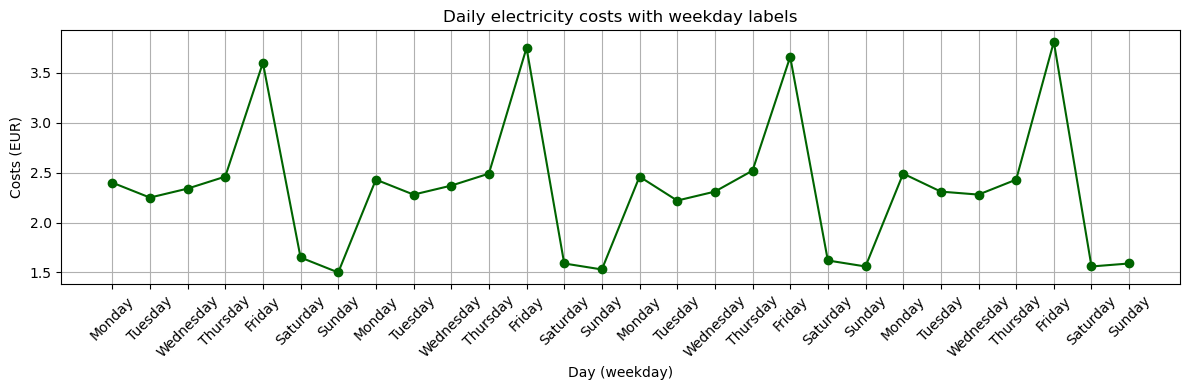

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(daily_costs_eur, color="darkgreen", marker="o")
plt.title("Daily electricity costs with weekday labels")
plt.xlabel("Day (weekday)")
plt.ylabel("Costs (EUR)")
plt.grid(True)

plt.xticks(
    ticks=list(range(28)),
    labels=weekday_names,
    rotation=45
)

plt.tight_layout()
plt.show()

Hier ist wichtig zu verstehen, was `list(range(28))` macht.
Die Funktion `range(28)` erzeugt eine Folge von Zahlen von 0 bis 27.
Wenn wir diese in list(...) hineinstecken, wird daraus eine echte Python‑Liste.

Für unseren Plot wollen wir Ticks (Markierungen) bei allen Tagesindizes von 0 bis 27 setzen.
Deshalb geben wir `ticks=list(range(28))` an.

Mit `labels=weekday_names` sagen wir, welche Texte zu diesen Positionen gehören.
Das sind unsere Wochentagsnamen, die wir vorher gebaut haben.
Durch `rotation=45` drehen wir die Beschriftungen etwas, damit sie besser lesbar sind.

Im ersten Plot hatten wir nur Zahlen auf der x‑Achse.
Jetzt sehen wir zu jedem Punkt den Wochentag, an dem er stattgefunden hat.
Damit wird in der Grafik deutlich sichtbar, dass bestimmte Wochentage immer höhere Kosten verursachen als andere.

## Was passiert freitags!?

Unser Verdacht hat sich bestätigt: Am Freitag ist der Stromverbrauch immer viel höher als sonst. Nach einem kurzen Verhör... ähh... Gespräch stellen wir fest: Person A und Person B fahren am Wochenende immer nach Hause zu den Eltern um Wäsche zu waschen, aber Person C benutzt am Freitag immer die Waschmaschine und Trockner der WG. Empörung macht sich in der WG breit. Ist es dann überhaupt fair, sich die Stromkosten gleich aufzuteilen? Dem wollen wir auf den Grund gehen.

Berechnen wir einfach die durchschnittlichen Kosten von einem Freitag und von einem sogenannten "nicht-Freitag". Dazu können wir wieder unsere Wochentag-Liste verwenden:

In [12]:
friday_sum_eur = 0.0
other_days_sum_eur = 0.0


for it in range(28):
    weekday_name = weekday_names[it]

    # Costs for this day
    cost_for_this_day = daily_costs_eur[it]

    # Decide if this is a Friday or not
    if weekday_name == "Friday":
        friday_sum_eur += cost_for_this_day #x+=1 is short for x = x + 1
    else:
        other_days_sum_eur += cost_for_this_day

average_friday_cost_eur = friday_sum_eur / 4
average_other_days_cost_eur = other_days_sum_eur / (28 - 4)

print("Average costs on Fridays (EUR):", average_friday_cost_eur)
print("Average costs on non-Friday days (EUR):", average_other_days_cost_eur)

Average costs on Fridays (EUR): 3.705
Average costs on non-Friday days (EUR): 2.1100000000000008


Der Unterschied ist also nicht ganz 2 Euro pro Freitag und somit zwischen 6 und 7 Euro im Monat. Da könnte man schon überlegen, ob man die Stromkosten nicht fairer aufteilen will. Wobei, ob es wirklich fairer wäre, ist eine sehr viel komplexere Frage. Da müsste man sich schon konkretere Gedanken über Gleichverteilung machen und die Hintergründe, warum Person C anders wäscht (waschen muss?) beleuchten. Und natürlich würde das die Frage nach dem Umweltkosten aufwerfen, die ja gerade im Bereich Mobilität nicht wirklich gut mit den monetären Kosten korrelieren. Egal. Für Erste können wir stolz sein, das Geheimnis des Freitags quantitativ gelöst zu haben.

Die Berechnung, was ein Freitag kostet könnte man übrigens auch ganz ohne Schleife machen. In dem man Listen **Sliced**.

## Slicing: Teile einer Liste auswählen

Unter **Slicing** versteht man in Python das Auswählen von einem Stück einer Liste.
Statt immer die ganze Liste zu betrachten, kann man sich nur bestimmte Einträge herausnehmen.

**Einen einzelnen Eintrag auswählen**

Das kennen wir schon:  
Mit `daily_costs_eur[0]` holen wir uns den ersten Eintrag (Index 0), also die Kosten für den ersten Tag.  
Mit `daily_costs_eur[5]` holen wir den Eintrag mit Index 5, den sechsten Tag.

Hier steht in der eckigen Klammer immer genau eine Zahl.  

**Ein Stück der Liste: erste Woche**

Beim Slicing wählen wir mehrere Einträge auf einmal aus.
Das macht man mit zwei Zahlen in der Klammer, getrennt durch einen Doppelpunkt:

`first_week_costs = daily_costs_eur[:7]`

Das bedeutet:

Wir nehmen alle Einträge vor Index 7.  
Also die Einträge mit Index 0, 1, 2, 3, 4, 5 und 6 – das sind sieben Tage, unsere erste Woche.


**Letzte Woche: von x bis zum Ende**

Wir können auch ein Stück „von x bis zum Ende der Liste“ nehmen:

`last_week_costs = daily_costs_eur[21:]`

Hier steht vor dem Doppelpunkt die Zahl 21, dahinter nichts.  
Das bedeutet: Wir nehmen alle Einträge ab Index 21 bis zum Ende der Liste.  
Das sind die letzten sieben Tage, also die vierte Woche.  

**Woche 2: von x bis y**

Die zweite Woche liegt in der Mitte.
Wenn wir wissen, dass sie bei Index 7 beginnt und bei Index 14 aufhört, können wir schreiben:

`second_week_costs = daily_costs_eur[7:14]`

Wichtig ist dabei der Merksatz:

*x ist der erste Eintrag, den man haben will.*  
*y ist der erste Eintrag, den man nicht mehr haben will.* 

In `daily_costs_eur[x:y]` ist x inklusive und y exklusiv.

Das sind die Einträge mit Index 7, 8, 9, 10, 11, 12 und 13.
Index 14 ist der erste Eintrag, den wir nicht mehr haben, daher ist er nicht dabei.

**Jeder Freitag**

Es gibt sogar noch leistungsfähigere slices:  
`liste[start:stop:step]`  
`start` ist der erste wert den wir wollen (freilassen für 0), `stop` der erste den wir nicht wollen (freilassen für bis zum ende) und `step` die Schrittweite, also wie viele Werte wir zwischendrin auslassen wollen. Mit dem `sum` Befehl, der eine Liste aufsummiert, klappt unsere Rechnung also extrem kompakt, ohne Schleife oder weitere Liste:

In [14]:
print(sum(daily_costs_eur[4::7]/4))

3.705


## Smarte Steckdosen

Person C (nennen wir sie gemäß alter Tradition Carol ([relevant xkcd](https://www.explainxkcd.com/wiki/index.php/1323:_Protocol))) möchte der Sache jetzt natürlich genauer auf den Grund gehen. Was wenn, die anderen beiden (Alice und Bob) am Freitag auch mehr Strom verbraucht?  

Zum Glück hat die WG einmal smarte Steckdosen installiert. Da die App dazu aber nicht mit der Android-Version von Carol kompatibel war, haben sie sie bislang nicht genutzt. Jetzt will es Carol aber wissen: Sie emuliert auf ihrem Laptop eine alte Android-Version und installiert eine Smart-Steckdosen App mit dem vertrauenserweckenden Namen *Ultimate PowerTech Electricity IoT Smart Life Manager* über eine informelle Quelle (der echte Appstore hatte diese App aus irgendeinem Grund nicht...). Die App startet und lässt sich mit den Steckdosen verbinden, aber bei der Auswertung stürzt die app immer ab. Aber: Carol bekommt die Rohdaten: Eine Liste, in der jedes Mal der Name der Steckdose steht, wenn 10 Wh verbraucht wurden:


In [2]:
events = [
    "Waschmaschine",
    "Computer1",
    "Waschmaschine",
    "Computer2",
    "Trockner",
    "Laufband",
    "Computer2",
    "Waschmaschine",
    "Brotbackmaschine",
    "Computer1",
    "Trockner",
    "Laptop",
    "Computer2",
     "Trockner",
    "Waschmaschine",
    "Trockner",
]

Wir wissen zwar, wem welches Gerät gehört (die Brotbackmaschine gehört zum Beispiel Bob), aber wie sollen wir das jetzt auswerten und zusammenzählen? Eine einfache Liste hilft uns hier nicht weiter, da das "Mapping" (also welcher Wert mit welchem ersetzt werden soll) viel zu kompliziert ist. Bei Wochentagen war es einfach: Jede 0 soll zu "Monday" werden. Jetzt hätten wir gern, dass Trockner, Waschmaschine und Laptop zu Carol wird. Wie könnten wir das umsetzen?

Eine Möglichkeit wäre eine Kette von If-Abfragen: Wenn Waschmaschine dann Carol. Wenn Laptop dann Carol. Und so weiter. Möglich, aber umständlich und fehleranfällig. Viel einfacher geht es mit **Dictionaries**.


Ein Dictionary ist eine Datenstruktur, in der wir zu einem „Schlüssel“ (Key) einen „Wert“ nachschlagen können.
Ein Schlüssel kann eine Zahl, ein Wort oder etwas anderes sein, und zu jedem Schlüssel gehört genau ein Wert.

Wir sagen dem Dictionary also einfach, welche Geräte aus der Liste Alice, Bob und Carol gehören.

Dictionaries sind immer so aufgebaut:

```
name_of_dictonary = {
key1: wert1,
key2: wert2,
key3: wert3, 
...

}
```
Also in unserem Fall:


In [4]:
device_to_person = {

    "Computer1":    "Alice",
    "Laufband":          "Alice",

    "Computer2":      "Bob",
    "Brotbackmaschine":  "Bob",

    "Waschmaschine":     "Carol",
    "Trockner":          "Carol",
    "Laptop":      "Carol",
}

Damit können wir die Liste aus Geräten jetzt problemlos in eine Liste von Namen verwandeln. Die Namen müssen wir dann einfach aufsummieren und wir wissen wer am Freitag wie viel Strom verbraucht hat. Wo wollen wir den Stromverbrauch der einzelnen Personen jetzt aber speichern? Eine Liste mit 3 Elementen wäre ordentlich. Aber 3 getrennte Variablen haben den Vorteil, dass wir sie wirklich alice, bob und carol nennen könnten. Ein Dictionary ist best of both: ordentlich und man sieht gleich direkt welcher Eintrag sich auf welche Person bezieht.

In [5]:
usage_per_person_wh = {
    "Alice": 0,
    "Bob": 0,
    "Carol": 0,
}

for it in range(len(events)) :
    person = device_to_person[events[it]]  # direct lookup via key

    usage_per_person_wh[person] += 10  # 10 Wh per entry

print(usage_per_person_wh)

{'Alice': 30, 'Bob': 40, 'Carol': 90}


Es sieht ganz so aus, als würde Carol tatsächlich mehr Strom brauchen, als die anderen beiden. Somit bietet sie natürlich an, sich in Zukunft auch mehr an den Stromkosten zu beteiligen. Sie besprechen das kurz und kommen zum Schluss, dass die Daten aus *Ultimate PowerTech Electricity IoT Smart Life Manager* vielleicht generell keine gute Grundlage sind, irgendwelche Entscheidungen zu treffen. Und ein mal im Monat etwa 3 Euro zu überweisen kommt ihnen auch komisch vor. Also starten sie einfach einen neue WG-Tradition: Jeden ersten Freitag im Monat kauft Carol morgens Frühstück beim Bäcker und nimmt auch je ein Gebäckstück für Alice und Bob mit, das sie dann gemeinsam essen. Eine sehr viel schönere Lösung als ein Sepa-Lastschriftmandat.

## Zusammenfassung

### Listen und Arrays
Eine Liste ist die einfache, eingebaute Datenstruktur in Python, um mehrere Werte in einer Reihenfolge zu speichern. Wenn man eine Liste mit einer Ganzzahl multipliziert wird die Liste wiederholt, nicht jedes Element multipliziert. Ein Array aus numpy sieht ähnlich aus, ist aber für Rechenoperationen optimiert: bei array * zahl wird jedes Element einzeln multipliziert. Man konvertiert eine Liste in ein Array mit np.array(meine_liste).




### list(range(n))
range(n) erzeugt eine Folge von Zahlen von 0 bis n−1, die sich gut für Schleifen eignet. Wenn man diese Folge als echte Liste braucht, etwa für Achsenticks im Plot, verwendet man `list(range(n))`. So erhält man z.B. mit `list(range(5))` die Liste `[0, 1, 2, 3, 4]`.

### Slicing
Beim Slicing wählt man einen zusammenhängenden Abschnitt aus einer Liste aus. Mit `liste[x:y]` bekommt man alle Einträge ab Index x bis vor Index y. Merksatz: x ist der erste Eintrag, den man haben will; y ist der erste Eintrag, den man nicht mehr haben will. So kann man einzelne Wochen oder gezielt bestimmte Tage herausgreifen, ohne die ganze Liste zu bearbeiten.

### Dictionaries
Ein Dictionary verknüpft Schlüssel mit Werten. Statt über Positionen (0, 1, 2, …) zuzugreifen, fragt man über sinnvolle Schlüssel wie Zahlen oder Wörter nach. Mit `mein_dict[schluessel]` liest man den passenden Wert aus. Dictionaries eignen sich gut als „Nachschlage‑Tabellen“, aber haben noch viele andere Anwendungen. Dictonaries erstellt man mit  
```
name_of_dictonary = {
key1: wert1,
key2: wert2,
key3: wert3, 
...

}
```



